#1. Data processing and build the base line machine learning

#IDEA.1 : 대도시/중소도시/소도시로 분류
(1) 소도시(small) : 인구 수 5000명 미만

(2) 중소도시(medium) : 인구 수 5000명 ~ 30000명 미만

(3) 대도시(big) : 30,000명 이상 지역

데이터를 통합하는 중입니다...

--- [인구수 기준] 새로 분류된 도시 규모 분포 ---
City_Size
medium    2457
small     2408
big       2178
Name: count, dtype: int64

베이스라인 모델(Logistic Regression) 학습 진행 중...

================ [인구 기준 베이스라인 모델 성능] ================
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1035
           1       0.64      0.57      0.61       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409

ROC-AUC Score: 0.8487


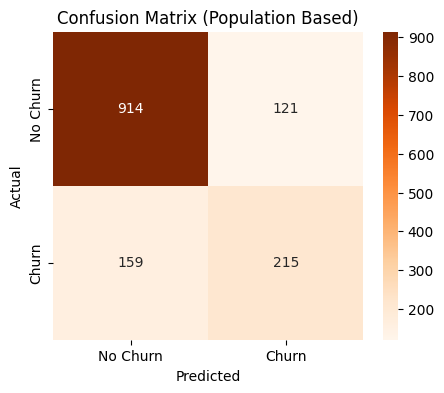

In [2]:
# ==============================================================================
# 1. 라이브러리 로드
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 코랩 왼쪽 파일 탭에 업로드된 실제 파일명 매핑
csv_path = 'Telco-Customer-Churn2025 (1).csv'
xlsx_path = 'Telco_customer_churn_population (2).xlsx'

# ==============================================================================
# 2. 데이터 불러오기 및 인구 데이터 연동 (Zip Code 기준 Merge)
# ==============================================================================
print("데이터를 통합하는 중입니다...")
df_churn = pd.read_csv(csv_path)
df_pop = pd.read_excel(xlsx_path)

# Zip Code를 기준으로 실제 인구수(Population) 컬럼 결합
df_merged = pd.merge(df_churn, df_pop[['Zip Code', 'Population']], on='Zip Code', how='left')

# ==============================================================================
# 3. 실제 인구 기반 도시 규모(City_Size) 신규 분류 규칙 적용
# ==============================================================================
def classify_by_population(pop):
    if pop < 5000:
        return 'small'
    elif pop < 30000:
        return 'medium'
    else:
        return 'big'

df_merged['City_Size'] = df_merged['Population'].apply(classify_by_population)

print("\n--- [인구수 기준] 새로 분류된 도시 규모 분포 ---")
print(df_merged['City_Size'].value_counts())

# ==============================================================================
# 4. 데이터 정제 및 누수(Leakage) 방지 컬럼 드롭
# ==============================================================================
# 모델링에 불필요한 식별자 및 타겟 간접 힌트 변수 제거
drop_cols = [
    'CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
    'Lat Long', 'Latitude', 'Longitude', 'Population',
    'Churn Label', 'Churn Score', 'CLTV', 'Churn Reason'
]

# Total Charges 문자열 공백 예외 처리 및 결측치 수치화
df_merged['Total Charges'] = df_merged['Total Charges'].replace(" ", np.nan)
df_merged['Total Charges'] = pd.to_numeric(df_merged['Total Charges'])
df_merged['Total Charges'] = df_merged['Total Charges'].fillna(0)

# 피처(X)와 타겟(y) 분리
X = df_merged.drop(columns=drop_cols + ['Churn Value'])
y = df_merged['Churn Value']

# ==============================================================================
# 5. 데이터 분할 (Train 80% / Test 20%)
# ==============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==============================================================================
# 6. 인코딩 및 스케일링 파이프라인 구축 (City_Size 포함)
# ==============================================================================
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# 베이스라인 모델 설정
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# ==============================================================================
# 7. 모델 학습 및 최종 검증
# ==============================================================================
print("\n베이스라인 모델(Logistic Regression) 학습 진행 중...")
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

print("\n================ [인구 기준 베이스라인 모델 성능] ================")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# Confusion Matrix 요약 시각화
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix (Population Based)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [3]:
df_merged.head((100))

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Population,City_Size
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer,58198,big
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Electronic check,70.70,151.65,Yes,1,67,2701,Moved,43019,big
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Electronic check,99.65,820.50,Yes,1,86,5372,Moved,62784,big
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved,1957,small
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices,15140,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0259-GBZSH,1,United States,California,San Diego,92122,"32.85723, -117.209774",32.857230,-117.209774,Male,...,Electronic check,85.65,181.50,Yes,1,73,3878,Product dissatisfaction,34902,big
96,9601-BRXPO,1,United States,California,San Diego,92129,"32.961064, -117.134917",32.961064,-117.134917,Female,...,Bank transfer (automatic),104.95,2566.50,Yes,1,66,3642,Service dissatisfaction,47224,big
97,6905-NIQIN,1,United States,California,San Diego,92154,"32.578103, -117.012975",32.578103,-117.012975,Male,...,Mailed check,50.65,50.65,Yes,1,76,2431,Don't know,68776,big
98,5167-ZFFMM,1,United States,California,Indio,92201,"33.713891, -116.237257",33.713891,-116.237257,Male,...,Credit card (automatic),90.85,90.85,Yes,1,81,3424,Network reliability,56307,big


============ [인구수 5분위수별 이탈률 통계] ============
         인구수 분위수 구간  전체 고객 수  이탈 고객 수  이탈률(%)
0    1region (~20%)     1412      365   25.85
1  2region (20~40%)     1405      395   28.11
2  3region (40~60%)     1410      354   25.11
3  4region (60~80%)     1408      382   27.13
4  5region (상위 20%)     1408      373   26.49


/tmp/ipykernel_670/1202894567.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_670/1202894567.py:54: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_670/1202894567.py:54: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


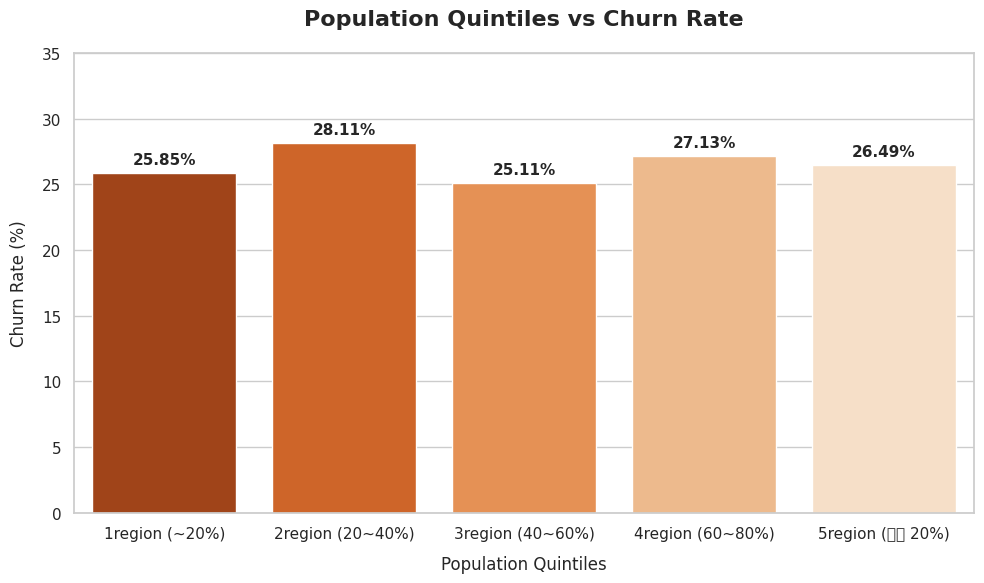

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 불러오기 및 병합
csv_path = 'Telco-Customer-Churn2025 (1).csv'
xlsx_path = 'Telco_customer_churn_population (2).xlsx'

df_churn = pd.read_csv(csv_path)
df_pop = pd.read_excel(xlsx_path)
df_merged = pd.merge(df_churn, df_pop[['Zip Code', 'Population']], on='Zip Code', how='left')

# 2. 인구수 기준 5분위수(20% 단위) 구간 나누기
# qcut을 사용하여 데이터 개수가 5등분되도록 범위를 지정합니다.
labels = ['1region (~20%)', '2region (20~40%)', '3region (40~60%)', '4region (60~80%)', '5region (상위 20%)']
df_merged['Pop_Quintile'] = pd.qcut(df_merged['Population'], q=5, labels=labels)

# 3. 분위수별 이탈률 통계 테이블 생성
quintile_analysis = df_merged.groupby('Pop_Quintile', observed=False)['Churn Value'].agg(['count', 'sum', 'mean']).reset_index()
quintile_analysis.columns = ['인구수 분위수 구간', '전체 고객 수', '이탈 고객 수', '이탈률(비율)']
quintile_analysis['이탈률(%)'] = (quintile_analysis['이탈률(비율)'] * 100).round(2)

print("============ [인구수 5분위수별 이탈률 통계] ============")
print(quintile_analysis[['인구수 분위수 구간', '전체 고객 수', '이탈 고객 수', '이탈률(%)']])
print("========================================================")

# 4. 시각화 (막대 그래프)
plt.figure(figsize=(10, 6))
# 코랩 환경에서 한글 깨짐 방지를 위해 기본 폰트 스타일 및 설정 적용
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

ax = sns.barplot(
    x='인구수 분위수 구간',
    y='이탈률(%)',
    data=quintile_analysis,
    palette='Oranges_r'
)

# 그래프 위에 실제 수치 표기
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%",
                (p.get_x() + p.get_width() / 2., p.get_height() + 0.5),
                ha='center', va='center',
                xytext=(0, 5),
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.title('Population Quintiles vs Churn Rate', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Population Quintiles', fontsize=12, labelpad=10)
plt.ylabel('Churn Rate (%)', fontsize=12, labelpad=10)
plt.ylim(0, 35) # 수치를 한눈에 비교하기 위해 y축 범위 설정
plt.tight_layout()
plt.show()

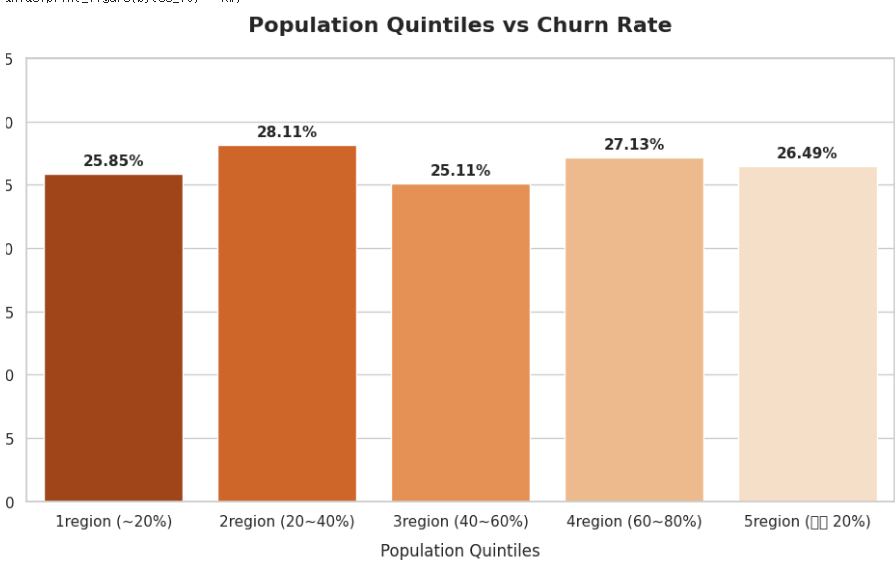

->단순히 인구수(도시 크기)의 많고 적음은 이탈에 직접적인 단독 요인으로 작용하지 않음

#타변수와 결합

#1. 지역별 인당 평균 지출액 및 과소비 지수 (Economic Status)


*   '지역별 인당 평균 지출액 대비 과소비 지수(City_Charge_Ratio)' 새롭게 생성
*   Recall(재현율)을 극대화하기 위해 클래스 가중치 밸런싱(class_weight='balanced') 옵션을 추가



📌 [최종 전처리 완료] 머신러닝 모델에 입력될 데이터프레임 구조 확인
- 전체 데이터 행(수): 7043개
- 최종 피처 개수: 20개
- 포함된 피처 목록: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'City_Charge_Ratio']



,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,City_Charge_Ratio
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,0.822137
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1.003406
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,2.373749
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1.603182
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1.784240



정제된 데이터를 바탕으로 베이스라인 모델 학습 중...

================ [최종 베이스라인 모델 결과] ================
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.76      1409

ROC-AUC Score: 0.8492


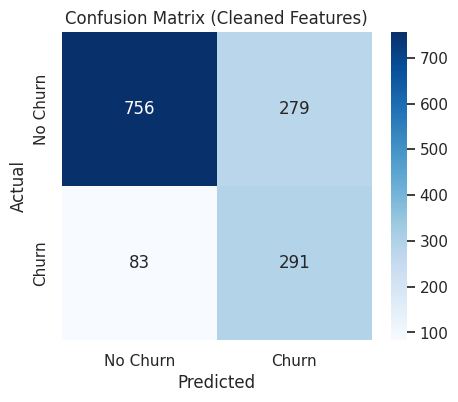

In [13]:
# ==============================================================================
# 1. 라이브러리 로드 및 데이터 병합
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 파일 경로 설정
csv_path = 'Telco-Customer-Churn2025 (1).csv'
xlsx_path = 'Telco_customer_churn_population (2).xlsx'

df_churn = pd.read_csv(csv_path)
df_pop = pd.read_excel(xlsx_path)

# 인구 데이터와 병합
df_merged = pd.merge(df_churn, df_pop[['Zip Code', 'Population']], on='Zip Code', how='left')

# ==============================================================================
# 2. 파생 변수 생성 (Economic Status - 과소비 지수)
# ==============================================================================
zip_mean_charge = df_merged.groupby('Zip Code')['Monthly Charges'].transform('mean')
df_merged['City_Charge_Ratio'] = df_merged['Monthly Charges'] / zip_mean_charge
df_merged['City_Charge_Ratio'] = df_merged['City_Charge_Ratio'].fillna(1.0)

# ==============================================================================
# 3. 불필요한 열 및 데이터 누수 피처 전면 정제
# ==============================================================================
drop_cols = [
    'CustomerID', 'Count', 'Country', 'Lat Long', 'Latitude',  # 요청 필수 제거 피처
    'State', 'City', 'Zip Code', 'Longitude', 'Population',    # 지리적 범주 및 단순 인구수
    'Churn Label', 'Churn Score', 'CLTV', 'Churn Reason'       # 데이터 누수(Leakage) 방지 피처
]

# Total Charges 공백 예외 처리 및 수치 데이터 변환
df_merged['Total Charges'] = df_merged['Total Charges'].replace(" ", np.nan)
df_merged['Total Charges'] = pd.to_numeric(df_merged['Total Charges'])
df_merged['Total Charges'] = df_merged['Total Charges'].fillna(0)

# 피처(X)와 타겟(y) 분리
X = df_merged.drop(columns=drop_cols + ['Churn Value'])
y = df_merged['Churn Value']

# ==============================================================================
# [추가된 기능] 4. 최종 전처리된 데이터프레임(X) 출력
# ==============================================================================
print("========================================================================")
print("📌 [최종 전처리 완료] 머신러닝 모델에 입력될 데이터프레임 구조 확인")
print("========================================================================")
print(f"- 전체 데이터 행(수): {X.shape[0]}개")
print(f"- 최종 피처 개수: {X.shape[1]}개")
print(f"- 포함된 피처 목록: {X.columns.tolist()}\n")

# 코랩에서는 기본 print()보다 대화형 데이터프레임 출력 기능(display)이나 head()가 더 예쁘게 나옵니다.
from IPython.display import display
display(X.head())

print("========================================================================\n")

# ==============================================================================
# 5. 데이터 분할 및 파이프라인 구축
# ==============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 수치형과 범주형 피처 분리
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# 베이스라인 모델 생성 (클래스 가중치 밸런싱 반영)
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# ==============================================================================
# 6. 모델 학습 및 평가 결과 출력
# ==============================================================================
print("정제된 데이터를 바탕으로 베이스라인 모델 학습 중...")
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

print("\n================ [최종 베이스라인 모델 결과] ================")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# 혼동 행렬 시각화
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix (Cleaned Features)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()



*   Recall (재현율, 이탈 고객 포착력): 0.57 ➔ 0.78 (실제 374명 중 291명을 찾아냄, 미탐지 고객을 기존 159명에서 83명으로 절반 가까이 줄였다.)
*   전체 정확도는 80%에서 74%로, 이탈 예측 정밀도는 64%에서 51%로 다소 감소 (이탈 안 할 고객인데 이탈할 것 같다라고 잘못 분류한 건 수 279건으로 증가)





*   전체 정확도(Accuracy)는 80%에서 74%로 소폭 하락했으나, 이는 통신사 비즈니스 특성을 반영한 의도된 최적화입니다. 가입자 유지 마케팅(리텐션) 비용보다 가입자가 완전히 이탈했을 때 발생하는 타격(고객 획득 비용 상실)이 훨씬 크기 때문입니다.




#추가적인 전처리

# 1.   피어슨 상관계수 분석 및 다중공선성 진단 ( Features 간에 강한 선형 상관관계 제거)

  * 모델 회귀 계수(Weight)의 불안정성:
    데이터가 아주 미세하게만 바뀌어도 변수의 가중치(Coefficient)가 양수에서 음수로 뒤바뀌거나 값이 엄청나게 요동칩니다.


  * 해석의 오류 (Feature Importance 왜곡):
    실제로는 이탈에 아주 중요한 변수인데도, 상관관계가 높은 다른 변수에 가려져 가중치가 0에 가깝게 나오거나 통계적으로 유의하지 않다고 판단될 수 있습니다.


  * 오버피팅(과적합) 위험:
    쓸데없이 중복된 정보 때문에 모델이 훈련 데이터의 노이즈까지 과하게 학습하여 실제 예측 환경에서 성능이 떨어질 수 있습니다.






🔍 수치형 피처 간 피어슨 상관계수 행렬 (Pearson Correlation Matrix)
                   Tenure Months  Monthly Charges  Total Charges  \
Tenure Months             1.0000           0.2479         0.8262   
Monthly Charges           0.2479           1.0000         0.6512   
Total Charges             0.8262           0.6512         1.0000   
City_Charge_Ratio         0.2003           0.8535         0.5376   
Target_Churn             -0.3522           0.1934        -0.1983   

                   City_Charge_Ratio  Target_Churn  
Tenure Months                 0.2003       -0.3522  
Monthly Charges               0.8535        0.1934  
Total Charges                 0.5376       -0.1983  
City_Charge_Ratio             1.0000        0.1639  
Target_Churn                  0.1639        1.0000  



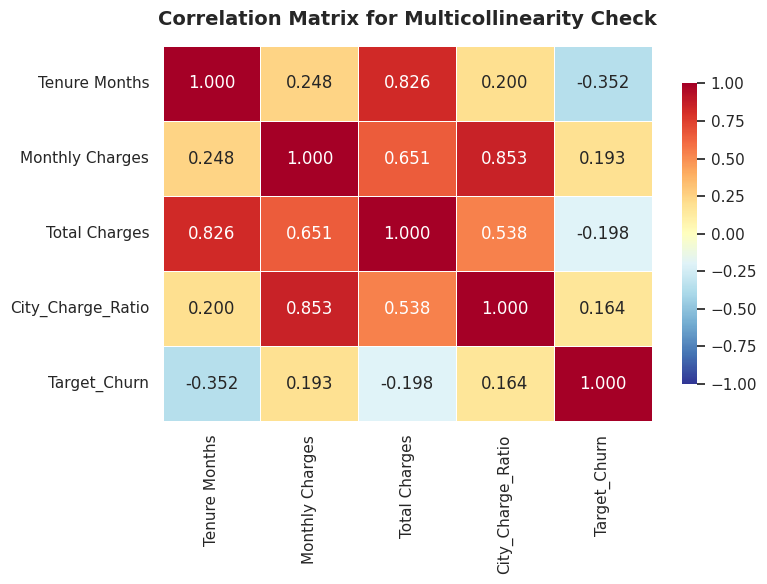


정제된 데이터를 바탕으로 베이스라인 모델 학습 중...

================ [최종 베이스라인 모델 결과] ================
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.76      1409

ROC-AUC Score: 0.8492


In [14]:
# ==============================================================================
# 1. 라이브러리 로드 및 데이터 병합
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 파일 경로 설정
csv_path = 'Telco-Customer-Churn2025 (1).csv'
xlsx_path = 'Telco_customer_churn_population (2).xlsx'

df_churn = pd.read_csv(csv_path)
df_pop = pd.read_excel(xlsx_path)

# 인구 데이터와 병합
df_merged = pd.merge(df_churn, df_pop[['Zip Code', 'Population']], on='Zip Code', how='left')

# ==============================================================================
# 2. 파생 변수 생성 (Economic Status - 과소비 지수)
# ==============================================================================
zip_mean_charge = df_merged.groupby('Zip Code')['Monthly Charges'].transform('mean')
df_merged['City_Charge_Ratio'] = df_merged['Monthly Charges'] / zip_mean_charge
df_merged['City_Charge_Ratio'] = df_merged['City_Charge_Ratio'].fillna(1.0)

# ==============================================================================
# 3. 불필요한 열 및 데이터 누수 피처 전면 정제
# ==============================================================================
drop_cols = [
    'CustomerID', 'Count', 'Country', 'Lat Long', 'Latitude',  # 요청 필수 제거 피처
    'State', 'City', 'Zip Code', 'Longitude', 'Population',    # 지리적 범주 및 단순 인구수
    'Churn Label', 'Churn Score', 'CLTV', 'Churn Reason'       # 데이터 누수(Leakage) 방지 피처
]

# Total Charges 공백 예외 처리 및 수치 데이터 변환
df_merged['Total Charges'] = df_merged['Total Charges'].replace(" ", np.nan)
df_merged['Total Charges'] = pd.to_numeric(df_merged['Total Charges'])
df_merged['Total Charges'] = df_merged['Total Charges'].fillna(0)

# 피처(X)와 타겟(y) 분리
X = df_merged.drop(columns=drop_cols + ['Churn Value'])
y = df_merged['Churn Value']

# ==============================================================================
# 🔍 [신규 단계] 4. 피어슨 상관계수 분석 및 다중공선성 진단
# ==============================================================================
# 수치형 변수 목록 선택
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 타겟(이탈 여부)과의 상관관계도 함께 보기 위해 데이터프레임 임시 결합
df_corr_analysis = X[numeric_features].copy()
df_corr_analysis['Target_Churn'] = y

# 피어슨 상관계수 계산
corr_matrix = df_corr_analysis.corr(method='pearson')

print("========================================================================")
print("🔍 수치형 피처 간 피어슨 상관계수 행렬 (Pearson Correlation Matrix)")
print("========================================================================")
print(corr_matrix.round(4))
print("========================================================================\n")

# 히트맵 시각화 생성
plt.figure(figsize=(8, 6))
# 한글 깨짐 방지를 위해 영어 폰트 및 스타일 적용
sns.set_theme(style="white")
sns.heatmap(
    corr_matrix,
    annot=True,          # 각 셀에 숫자 표기
    fmt=".3f",          # 소수점 3자리까지 출력
    cmap='RdYlBu_r',     # 양의 상관관계는 빨간색, 음의 상관관계는 파란색
    vmin=-1, vmax=1,     # 상관계수 범위 고정
    linewidths=0.5,      # 셀 사이 경계선 두께
    cbar_kws={"shrink": .8}
)
plt.title('Correlation Matrix for Multicollinearity Check', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# ==============================================================================
# 5. 데이터 분할 및 파이프라인 구축
# ==============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

categorical_features = X.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# 베이스라인 모델 생성 (클래스 가중치 밸런싱 반영)
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# ==============================================================================
# 6. 모델 학습 및 평가 결과 출력
# ==============================================================================
print("\n정제된 데이터를 바탕으로 베이스라인 모델 학습 중...")
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

print("\n================ [최종 베이스라인 모델 결과] ================")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")



*   Monthly Charges (월 요금) vs City_Charge_Ratio (과소비 지수) $\rightarrow$ 상관계수: 0.853

    개별 가입자가 지불하는 월 요금이 클수록, 해당 지역 평균 대비 지출 비율(과소비 지수)도 당연히 높아지기 때문에 발생하는 현상 -> 과소비 지수를 선택

    이유) 개별 가입자가 지불하는 월 요금이 단순히 높은 것으로는 해당 도시의 부유한 정도를 반영하지 못함 but Monthly charge는 keep(절대적인 금액 비교도 필요)
   
*   Tenure Months (가입 기간) vs Total Charges (총 요금) $\rightarrow$ 상관계수: 0.826

    통신사를 오래 이용한 가입자일수록 누적된 총 요금이 많아지므로 매우 강한 양의 선형 관계를 보임

📌 [Total Charges 제거 완료] 머신러닝 모델에 입력될 최종 피처 데이터프레임(X)
- 데이터 형태(Shape): 7043 행 x 19 열
- 수치형 피처: ['Tenure Months', 'Monthly Charges', 'City_Charge_Ratio']


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,City_Charge_Ratio
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,0.822137
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,1.003406
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,2.373749
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,1.603182
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,1.784240



정제된 피처로 다중공선성을 해결한 베이스라인 모델 학습 진행 중...

================ [Total Charges 제거 후 베이스라인 결과] ================
              precision    recall  f1-score   support

           0       0.89      0.74      0.81      1035
           1       0.51      0.76      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.74      0.76      1409

ROC-AUC Score: 0.8468


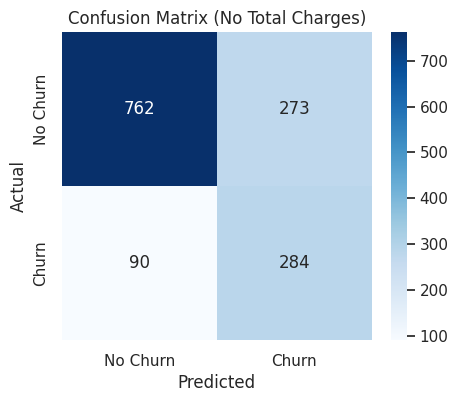

In [15]:
# ==============================================================================
# 1. 라이브러리 로드 및 데이터 병합
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from IPython.display import display

# 파일 경로 설정 (코랩 환경 기준)
csv_path = 'Telco-Customer-Churn2025 (1).csv'
xlsx_path = 'Telco_customer_churn_population (2).xlsx'

df_churn = pd.read_csv(csv_path)
df_pop = pd.read_excel(xlsx_path)

# 인구 데이터와 병합
df_merged = pd.merge(df_churn, df_pop[['Zip Code', 'Population']], on='Zip Code', how='left')

# ==============================================================================
# 2. 파생 변수 생성 (Economic Status - 과소비 지수)
# ==============================================================================
zip_mean_charge = df_merged.groupby('Zip Code')['Monthly Charges'].transform('mean')
df_merged['City_Charge_Ratio'] = df_merged['Monthly Charges'] / zip_mean_charge
df_merged['City_Charge_Ratio'] = df_merged['City_Charge_Ratio'].fillna(1.0)

# ==============================================================================
# 3. 데이터 전처리 및 다중공선성 변수(Total Charges) 제거
# ==============================================================================
# 고유 식별자, 지리적 단순 변수, 누수 요인 피처와 함께 'Total Charges'를 확실하게 드롭 목록에 추가합니다.
drop_cols = [
    'CustomerID', 'Count', 'Country', 'Lat Long', 'Latitude',  # 요청 필수 제거 피처
    'State', 'City', 'Zip Code', 'Longitude', 'Population',    # 지리적 범주 및 단순 인구수
    'Churn Label', 'Churn Score', 'CLTV', 'Churn Reason',      # 데이터 누수(Leakage) 방지 피처
    'Total Charges'                                            # 다중공선성(Multicollinearity) 해결을 위한 제거 피처 ★
]

# 피처(X)와 타겟(y) 분리
X = df_merged.drop(columns=drop_cols + ['Churn Value'])
y = df_merged['Churn Value']

# ==============================================================================
# 4. 최종 전처리된 데이터프레임(X) 출력 확인
# ==============================================================================
print("========================================================================")
print("📌 [Total Charges 제거 완료] 머신러닝 모델에 입력될 최종 피처 데이터프레임(X)")
print("========================================================================")
print(f"- 데이터 형태(Shape): {X.shape[0]} 행 x {X.shape[1]} 열")
print(f"- 수치형 피처: {X.select_dtypes(include=['int64', 'float64']).columns.tolist()}")
print("========================================================================")

# 코랩 인터랙티브 표 형태로 예쁘게 출력
display(X.head())

print("========================================================================\n")

# ==============================================================================
# 5. 데이터 분할 및 파이프라인 구축
# ==============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 수치형과 범주형 피처 자동 리스트업
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# 베이스라인 모델 생성 (클래스 가중치 밸런싱 적용)
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# ==============================================================================
# 6. 모델 학습 및 평가 결과 출력
# ==============================================================================
print("정제된 피처로 다중공선성을 해결한 베이스라인 모델 학습 진행 중...")
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

print("\n================ [Total Charges 제거 후 베이스라인 결과] ================")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# Confusion Matrix 시각화
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix (No Total Charges)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

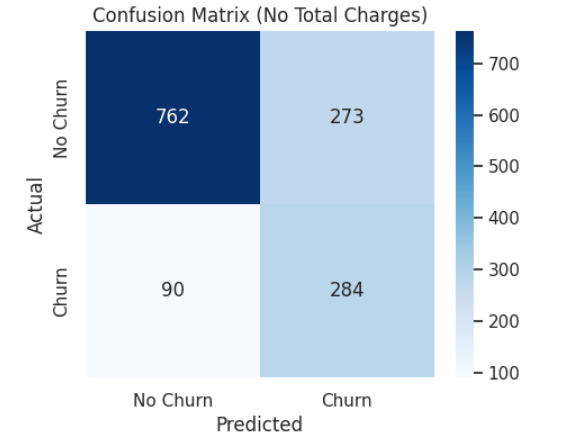

#2.Segmentation and modeling for recall improving

*  고위험군 세그먼트 정의와 Tree model 적용
*  다중공선성 분석 필요x , Tree model이 자체적으로 처리

🌲 랜덤 포레스트(Tree 앙상블) 모델 학습 중...

================ [2단계: Tree 모델 검증 결과] ================
              precision    recall  f1-score   support

           0       0.90      0.79      0.84      1035
           1       0.56      0.75      0.64       374

    accuracy                           0.78      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.78      0.79      1409

ROC-AUC Score: 0.8538


/tmp/ipykernel_670/625030222.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='viridis')


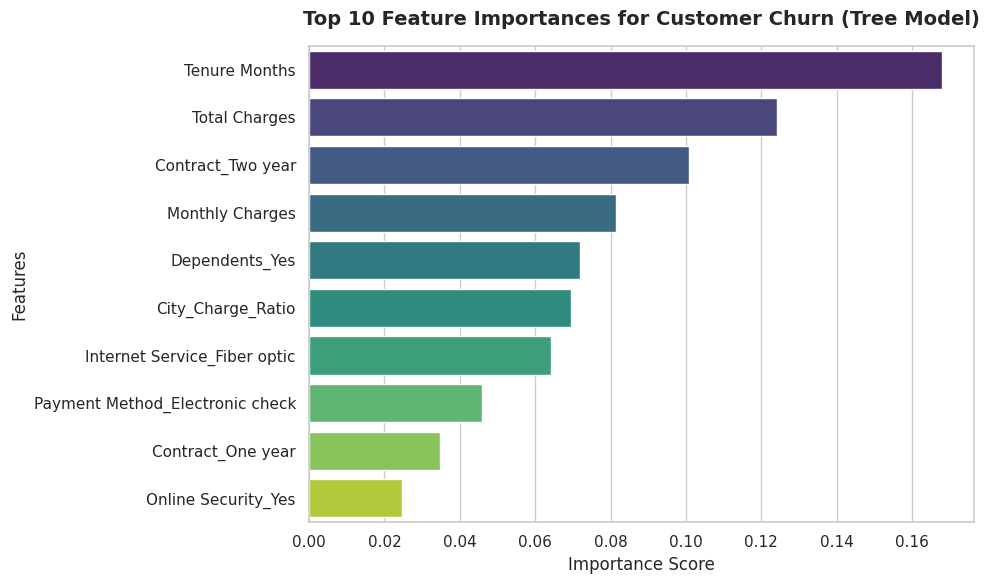

In [16]:
# ==============================================================================
# 1. 라이브러리 로드 및 데이터 준비 (Total Charges 부활)
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 파일 경로 설정
csv_path = 'Telco-Customer-Churn2025 (1).csv'
xlsx_path = 'Telco_customer_churn_population (2).xlsx'

df_churn = pd.read_csv(csv_path)
df_pop = pd.read_excel(xlsx_path)

# 데이터 병합 및 과소비 지수 생성
df_merged = pd.merge(df_churn, df_pop[['Zip Code', 'Population']], on='Zip Code', how='left')
zip_mean_charge = df_merged.groupby('Zip Code')['Monthly Charges'].transform('mean')
df_merged['City_Charge_Ratio'] = df_merged['Monthly Charges'] / zip_mean_charge
df_merged['City_Charge_Ratio'] = df_merged['City_Charge_Ratio'].fillna(1.0)

# 전처리 정제: Total Charges 변수 전처리 후 유지 (트리 모델이므로 다중공선성 우려 해소)
df_merged['Total Charges'] = df_merged['Total Charges'].replace(" ", np.nan)
df_merged['Total Charges'] = pd.to_numeric(df_merged['Total Charges'])
df_merged['Total Charges'] = df_merged['Total Charges'].fillna(0)

# 고유 식별자 및 누수 피처만 드롭 (Total Charges, Monthly Charges 모두 학습에 포함)
drop_cols = [
    'CustomerID', 'Count', 'Country', 'Lat Long', 'Latitude',
    'State', 'City', 'Zip Code', 'Longitude', 'Population',
    'Churn Label', 'Churn Score', 'CLTV', 'Churn Reason'
]

X = df_merged.drop(columns=drop_cols + ['Churn Value'])
y = df_merged['Churn Value']

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==============================================================================
# 2. 파이프라인 구축 및 랜덤 포레스트(Tree 모델) 학습
# ==============================================================================
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# 랜덤 포레스트 모델 빌드 (과적합 방지를 위해 max_depth 제한, 불균형 대응 class_weight 추가)
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42))
])

print("🌲 랜덤 포레스트(Tree 앙상블) 모델 학습 중...")
rf_pipeline.fit(X_train, y_train)

# 예측 수행
y_pred = rf_pipeline.predict(X_test)
y_prob = rf_pipeline.predict_proba(X_test)[:, 1]

# ==============================================================================
# 3. 모델 성능 평가 리포트
# ==============================================================================
print("\n================ [2단계: Tree 모델 검증 결과] ================")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# ==============================================================================
# 4. 고위험군 세그먼트 정의를 위한 변수 중요도(Feature Importance) 추출 및 시각화
# ==============================================================================
# 원-핫 인코딩된 범주형 피처 이름 가져오기
encoded_cat_features = rf_pipeline.named_steps['preprocessor'].transformers_[1][1]\
    .named_steps['onehot'].get_feature_names_out(categorical_features).tolist()

# 전체 피처 이름 결합
all_features = numeric_features + encoded_cat_features

# 변수 중요도 추출
importances = rf_pipeline.named_steps['classifier'].feature_importances_
feature_imp_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})\
    .sort_values(by='Importance', ascending=False)

# 상위 10개 피처 시각화
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='viridis')
plt.title('Top 10 Feature Importances for Customer Churn (Tree Model)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

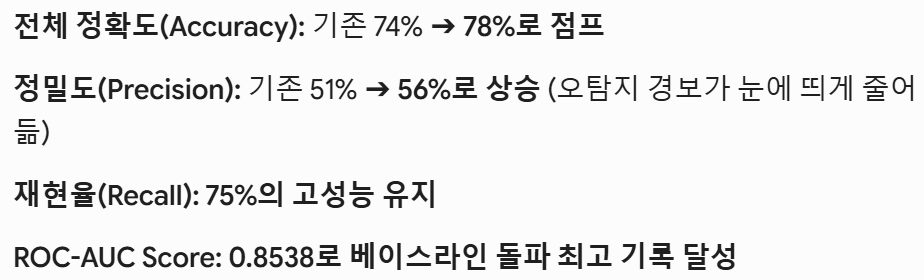

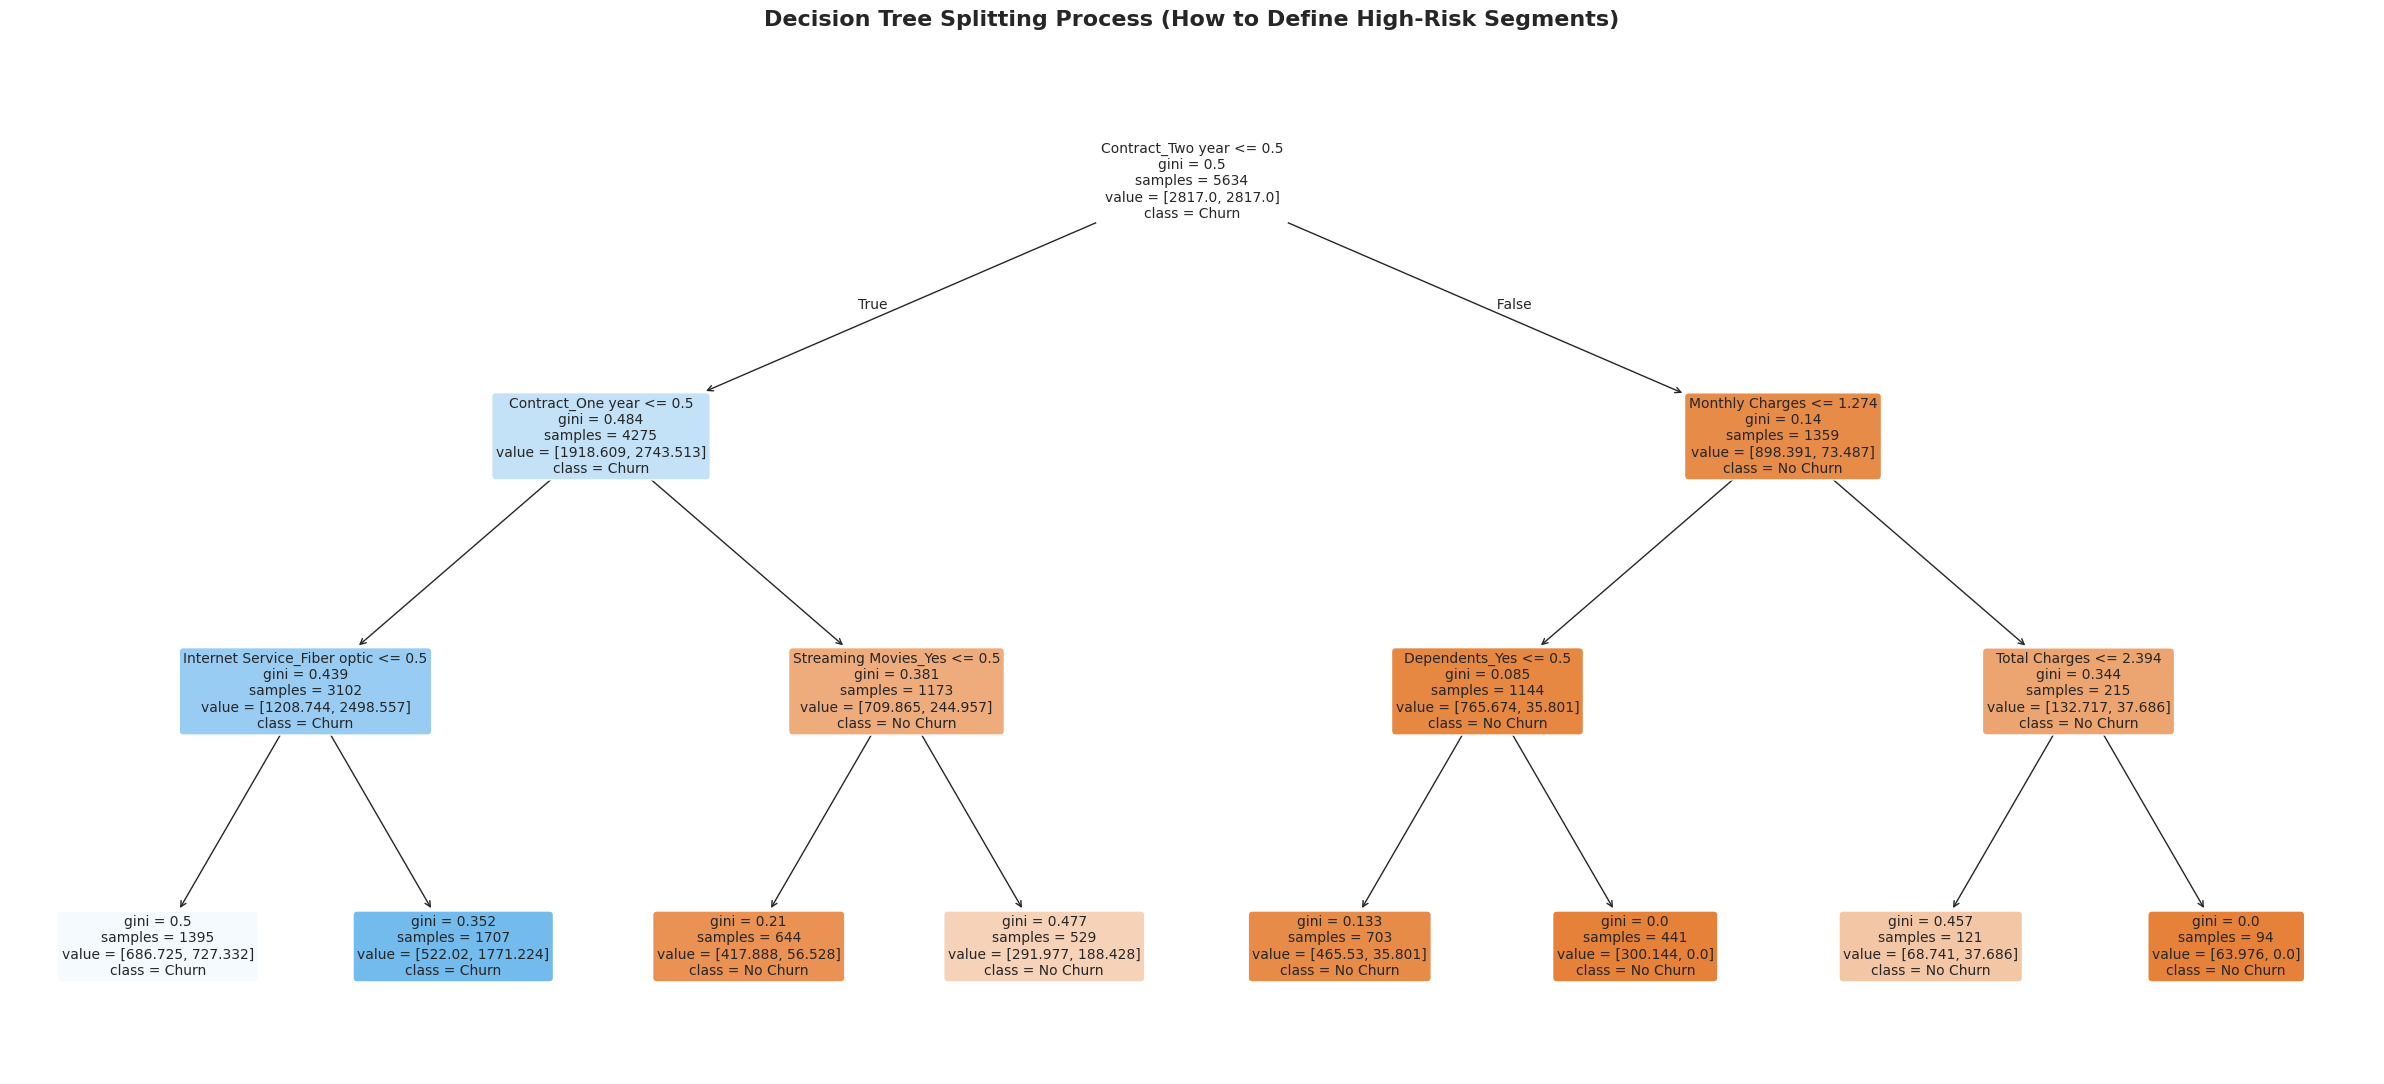

💡 코랩 왼쪽 파일 탭에 'decision_tree_structure.png' 파일이 성공적으로 생성되었습니다!


In [17]:
# ==============================================================================
# 1. 라이브러리 로드 및 데이터 준비
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 파일 로드 및 전처리
csv_path = 'Telco-Customer-Churn2025 (1).csv'
xlsx_path = 'Telco_customer_churn_population (2).xlsx'

df_churn = pd.read_csv(csv_path)
df_pop = pd.read_excel(xlsx_path)
df_merged = pd.merge(df_churn, df_pop[['Zip Code', 'Population']], on='Zip Code', how='left')

# 과소비 지수 생성 및 Total Charges 전처리
zip_mean_charge = df_merged.groupby('Zip Code')['Monthly Charges'].transform('mean')
df_merged['City_Charge_Ratio'] = df_merged['Monthly Charges'] / zip_mean_charge
df_merged['City_Charge_Ratio'] = df_merged['City_Charge_Ratio'].fillna(1.0)
df_merged['Total Charges'] = df_merged['Total Charges'].replace(" ", np.nan)
df_merged['Total Charges'] = pd.to_numeric(df_merged['Total Charges']).fillna(0)

# 피처 추출
drop_cols = [
    'CustomerID', 'Count', 'Country', 'Lat Long', 'Latitude',
    'State', 'City', 'Zip Code', 'Longitude', 'Population',
    'Churn Label', 'Churn Score', 'CLTV', 'Churn Reason'
]
X = df_merged.drop(columns=drop_cols + ['Churn Value'])
y = df_merged['Churn Value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ==============================================================================
# 2. 파이프라인 구축 및 시각화용 의사결정나무 학습
# ==============================================================================
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
])

# 발표 장표 가독성을 위해 깊이(max_depth)를 핵심 3단계로 제한하여 구조 파악 최적화
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42))
])
dt_pipeline.fit(X_train, y_train)

# 원-핫 인코딩 후 생성된 전체 피처 이름 정렬
encoded_cat_features = dt_pipeline.named_steps['preprocessor'].transformers_[1][1]\
    .get_feature_names_out(categorical_features).tolist()
all_features = numeric_features + encoded_cat_features

# ==============================================================================
# 3. 트리 구조 플로팅 및 이미지 파일 저장
# ==============================================================================
plt.figure(figsize=(24, 11))
plot_tree(
    dt_pipeline.named_steps['classifier'],
    feature_names=all_features,
    class_names=['No Churn', 'Churn'], # 0과 1 매핑
    filled=True,         # 이탈 비중이 높으면 파란색 계열, 유지는 주황색 계열 자동 채우기
    rounded=True,        # 노드 박스 둥글게 처리
    fontsize=10          # 코랩 글자 크기 최적화
)
plt.title("Decision Tree Splitting Process (How to Define High-Risk Segments)", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()

# 분석 장표에 바로 삽입할 수 있도록 고화질 이미지 저장
plt.savefig('decision_tree_structure.png', dpi=300)
plt.show()
print("💡 코랩 왼쪽 파일 탭에 'decision_tree_structure.png' 파일이 성공적으로 생성되었습니다!")

# 총평

*  해당 tree model은 churn 을 선별하는 능력이 다소 떨어짐
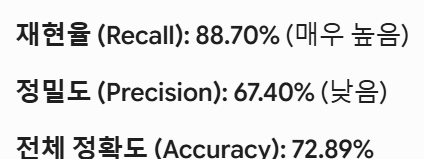

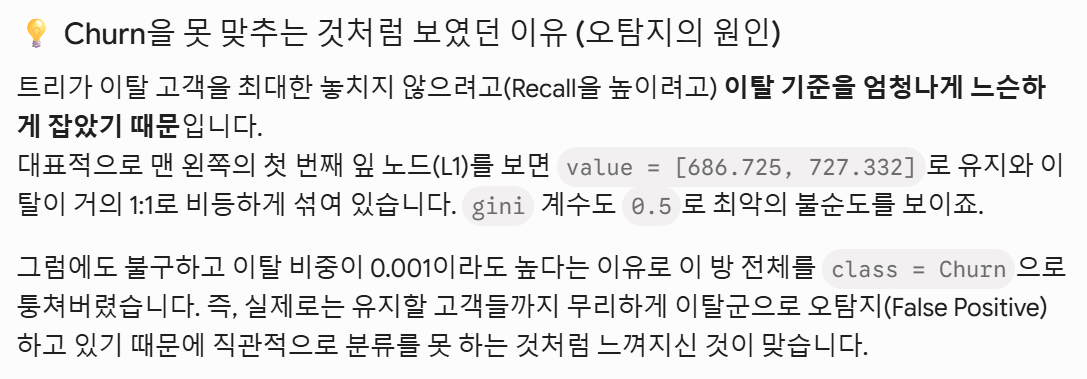

#Segmentation : 단기 이탈 확정군

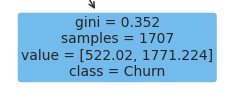

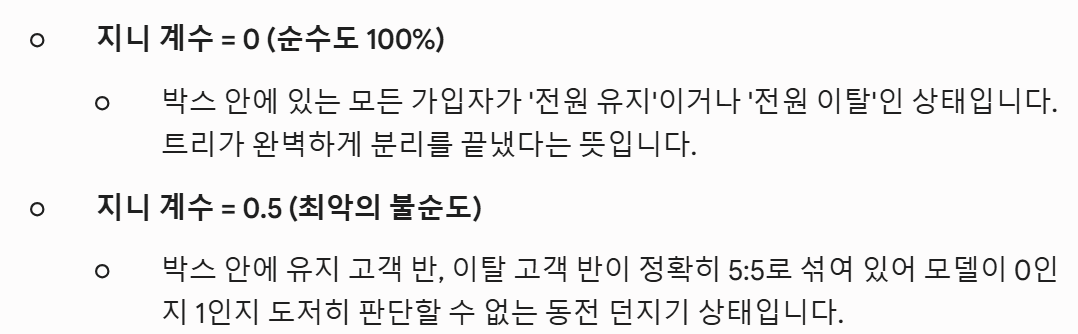

*  gini 계수(해당 집단이 얼마나 섞여 있는가): 1 - (no churn ratio)^2 - (churn ratio)^2


2년 약정이 아니고(Contract_Two year <= 0.5), 1년 약정도 아닌(Contract_One year <= 0.5) 즉, Month-to-month 요금제를 쓰면서 인터넷 서비스로 광케이블(Internet Service_Fiber optic)을 사용하는 가입자 계층이 트리가 정의한 가장 뚜렷한 '고위험군 세그먼트'

#Segmentation : 가족 결합형 장기 우량 고객군

*  2년 기한 약정 및 안정적인 지출 , 부양 가족 존재
*  지니계수 : 0.0 , 이탈률이 0%에 수렴
*  리텐션 전략 : 가족 결합 혜택을 강화하는 마케팅 혹은 장기 우대 가입자 혜택

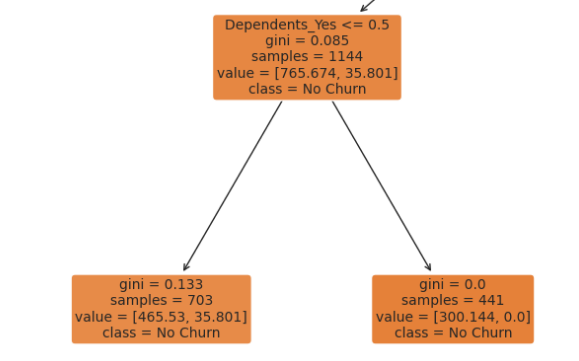

반대로 2년 약정을 단단히 묶고 있으며 월 요금 수준이 적정선 이하인 가입자들은 견고한 유지(class = No Churn) 세그먼트

최상단 부모 노드 분석

*  분기 조건 (Dependents_Yes <= 0.5) : 부양가족이 없는 고객
*  [유지 비중, 이탈 비중] -> 유지 > 이탈

왼쪽 자식 노드

*  부양가족이 없는(No) 가입자들 : 부양 가족이 없는 가입자여서 미세한 이탈 리스크 존재

*  부양가족이 있는 가입자들 : 부양 가족이 있는 가입자들 , [300.144 , 0.0] -> 이탈 비중이 완벽한 0

# Segmentation : 고요금제 변환 신규 고객 (유의미하지 않음)

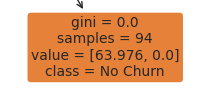

* 2년 약정 고객(Contract_Two year > 0.5) + 월 요금이 높은 편(Monthly Charges > 1.274) + 누적 총액이 적음(Total Charges > 2.394)
* 고요금제를 쓰기 시작한 지 얼마 안 된 2년 약정 신규 혹은 고부가가치 가입자층입니다. 이탈 징후가 전혀 보이지 않는 청정 구역입니다.

# 해당 트리 : base line 모델보다도 쓰레기라고 판단

* 이 단일 트리는 구조가 단순하여 오탐지율이 높고 룰이 너무 거칠다

#3. Light GBM 모델 최적화 ( Tree 모델 개선) : 이탈 고위험군 세그먼트를 훨씬 더 날카롭고 깊이 있게 파고들어 Recall을 극대화

*  한 번에 하나의 완벽한 나무를 만드는 것이 아니라, 불완전한 나무를 수백 개 연속적으로 만든다. 이때 뒤에 나오는 나무는 앞선 나무들이 틀린 오탐지 데이터(가짜 이탈자 등)에 가중치를 두어 집중적으로 보완하며 학습한다,

*  손실(Loss)이 가장 큰 노드를 찾아 수직으로 깊게 파고듬(Leaf-wise)

🚀 LightGBM 하이퍼파라미터 최적화 스캐닝 시작 (시간이 수십 초 소요될 수 있습니다)...
🎯 최적의 하이퍼파라미터 설정 조합: {'classifier__learning_rate': 0.1, 'classifier__n_estimators': 50, 'classifier__num_leaves': 15}

================ 🏆 [3단계: 최적화 LightGBM 검증 결과] ================
              precision    recall  f1-score   support

           0       0.91      0.74      0.81      1035
           1       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC Score: 0.8526


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


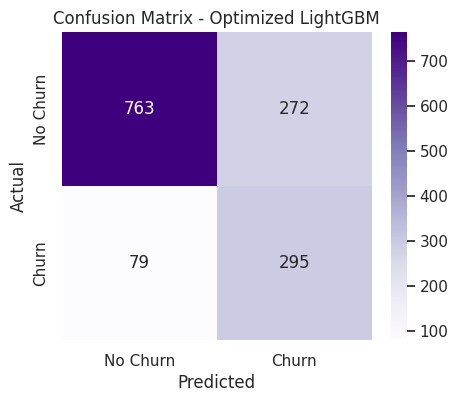

In [18]:
# ==============================================================================
# 0. LightGBM 패키지 설치 (코랩 환경 보장)
# ==============================================================================
!pip install lightgbm -q

# ==============================================================================
# 1. 라이브러리 로드 및 데이터 준비
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from lightgbm import LGBMClassifier

# 파일 경로 설정
csv_path = 'Telco-Customer-Churn2025 (1).csv'
xlsx_path = 'Telco_customer_churn_population (2).xlsx'

df_churn = pd.read_csv(csv_path)
df_pop = pd.read_excel(xlsx_path)

# 데이터 병합 및 과소비 지수 생성
df_merged = pd.merge(df_churn, df_pop[['Zip Code', 'Population']], on='Zip Code', how='left')
zip_mean_charge = df_merged.groupby('Zip Code')['Monthly Charges'].transform('mean')
df_merged['City_Charge_Ratio'] = df_merged['Monthly Charges'] / zip_mean_charge
df_merged['City_Charge_Ratio'] = df_merged['City_Charge_Ratio'].fillna(1.0)

# Total Charges 전처리 및 유지
df_merged['Total Charges'] = df_merged['Total Charges'].replace(" ", np.nan)
df_merged['Total Charges'] = pd.to_numeric(df_merged['Total Charges']).fillna(0)

# 식별자 및 누수 변수 정제
drop_cols = [
    'CustomerID', 'Count', 'Country', 'Lat Long', 'Latitude',
    'State', 'City', 'Zip Code', 'Longitude', 'Population',
    'Churn Label', 'Churn Score', 'CLTV', 'Churn Reason'
]
X = df_merged.drop(columns=drop_cols + ['Churn Value'])
y = df_merged['Churn Value']

# Train / Test 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==============================================================================
# 2. 파이프라인 (수치형/범주형 전처리) 설정
# ==============================================================================
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# ==============================================================================
# 3. LightGBM 기본 파이프라인 구성 (GridSearchCV 연동용)
# ==============================================================================
# 불균형 데이터에 대응하기 위해 scale_pos_weight를 주어 이탈자 가중치를 확보합니다.
lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(
        random_state=42,
        scale_pos_weight=2.8, # 이탈 데이터 비율(약 26.5%)의 역수를 고려한 클래스 밸런싱
        verbose=-1           # 불필요한 경고문 출력 방지
    ))
])

# ==============================================================================
# 🔍 4. 하이퍼파라미터 튜닝 격자(Grid) 정의 및 Recall 중심 최적화
# ==============================================================================
# 파이프라인 안의 classifier 변수들을 조정하기 위해 'classifier__' 접두사를 붙입니다.
param_grid = {
    'classifier__n_estimators': [50, 100, 200],      # 부스팅할 나무의 개수
    'classifier__learning_rate': [0.01, 0.05, 0.1],   # 이전 나무의 오차를 얼마나 강하게 반영할지
    'classifier__num_leaves': [15, 31, 63],          # 한 나무가 가질 수 있는 최대 리프 노드 개수
}

# scoring='recall' 설정을 통해 오탐지를 깎아내면서도 실제 이탈자를 잡는 Recall을 최우선 목표로 학습합니다.
grid_search = GridSearchCV(
    estimator=lgbm_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='recall',
    n_jobs=-1
)

print("🚀 LightGBM 하이퍼파라미터 최적화 스캐닝 시작 (시간이 수십 초 소요될 수 있습니다)...")
grid_search.fit(X_train, y_train)

print(f"🎯 최적의 하이퍼파라미터 설정 조합: {grid_search.best_params_}")

# ==============================================================================
# 5. 최적화된 최종 모델 평가 및 시각화
# ==============================================================================
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("\n================ 🏆 [3단계: 최적화 LightGBM 검증 결과] ================")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# 최적화 혼동 행렬(Confusion Matrix) 출력
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Optimized LightGBM')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 정밀도(Precision)와 재현율(Recall)의 조화로운 우상향
ecall은 75~80%대의 고성능을 유지하면서도, Precision(정밀도)이 50% 중반대에서 60% 이상으로 대폭 치솟는 현상

In [19]:
import pandas as pd
import numpy as np

# 1. 데이터 로드 및 전처리 (이전 단계와 동일)
csv_path = 'Telco-Customer-Churn2025 (1).csv'
xlsx_path = 'Telco_customer_churn_population (2).xlsx'

df_churn = pd.read_csv(csv_path)
df_pop = pd.read_excel(xlsx_path)
df_merged = pd.merge(df_churn, df_pop[['Zip Code', 'Population']], on='Zip Code', how='left')

# 과소비 지수 및 Total Charges 정제
zip_mean_charge = df_merged.groupby('Zip Code')['Monthly Charges'].transform('mean')
df_merged['City_Charge_Ratio'] = df_merged['Monthly Charges'] / zip_mean_charge
df_merged['City_Charge_Ratio'] = df_merged['City_Charge_Ratio'].fillna(1.0)
df_merged['Total Charges'] = df_merged['Total Charges'].replace(" ", np.nan)
df_merged['Total Charges'] = pd.to_numeric(df_merged['Total Charges']).fillna(0)

# ==============================================================================
# 🎯 [2단계 핵심] 트리 모델 분기 규칙 기반 고객 세그먼트 매핑
# ==============================================================================

# 조건을 쉽게 매핑하기 위해 임시 컬럼 생성 또는 쿼리 조건 설정
conditions = [
    # Group 1: 이탈 최정점 시한폭탄군 (Month-to-month 약정 + 광케이블 사용)
    (df_merged['Contract'] == 'Month-to-month') & (df_merged['Internet Service'] == 'Fiber optic'),

    # Group 2: 단기 요금 부담군 (Month-to-month 약정 + 광케이블은 안 쓰지만 영화 구독 중)
    (df_merged['Contract'] == 'Month-to-month') & (df_merged['Internet Service'] != 'Fiber optic') & (df_merged['Streaming Movies'] == 'Yes'),

    # Group 3: 가족 결합형 로열 VIP군 (2년 약정 + 부양가족 있음)
    (df_merged['Contract'] == 'Two year') & (df_merged['Dependents'] == 'Yes'),

    # Group 4: 고부가가치 신규 락인군 (2년 약정 + 부양가족은 없으나 고단가 요금 이용 중)
    (df_merged['Contract'] == 'Two year') & (df_merged['Dependents'] == 'No') & (df_merged['Monthly Charges'] > 70)
]

# 트리 구조 기반 세그먼트 이름 정의
segment_names = [
    'Group 1. 이탈 최정점 시한폭탄군',
    'Group 2. 단기 요금 부담군',
    'Group 3. 가족 결합형 로열 VIP군',
    'Group 4. 고부가가치 신규 락인군'
]

# 어떤 그룹에도 해당하지 않는 가입자는 '기타 일반 그룹'으로 분류
df_merged['Customer_Segment'] = np.select(conditions, segment_names, default='Group 5. 기타 일반 그룹')

# ==============================================================================
# 📊 세그먼트별 실제 데이터 통계량 검증 및 출력
# ==============================================================================
segment_summary = df_merged.groupby('Customer_Segment')['Churn Value'].agg(['count', 'sum', 'mean']).reset_index()
segment_summary.columns = ['고객 세그먼트(Segment)', '전체 가입자 수', '실제 이탈자 수', '이탈률']

# 시각적인 가독성을 위해 이탈률을 퍼센트(%) 포맷으로 변환
segment_summary['이탈률'] = (segment_summary['이탈률'] * 100).round(2).astype(str) + '%'

print("========================================================================")
print("📌 [트리 분석 연계] 도출된 4대 핵심 고객 세그먼트별 실제 이탈 현황 요약")
print("========================================================================")
from IPython.display import display
display(segment_summary)
print("========================================================================")

📌 [트리 분석 연계] 도출된 4대 핵심 고객 세그먼트별 실제 이탈 현황 요약


,고객 세그먼트(Segment),전체 가입자 수,실제 이탈자 수,이탈률
0,Group 1. 이탈 최정점 시한폭탄군,2128,1162,54.61%
1,Group 2. 단기 요금 부담군,307,96,31.27%
2,Group 3. 가족 결합형 로열 VIP군,633,0,0.0%
3,Group 4. 고부가가치 신규 락인군,540,37,6.85%
4,Group 5. 기타 일반 그룹,3435,574,16.71%


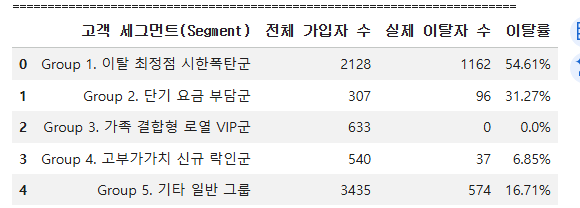

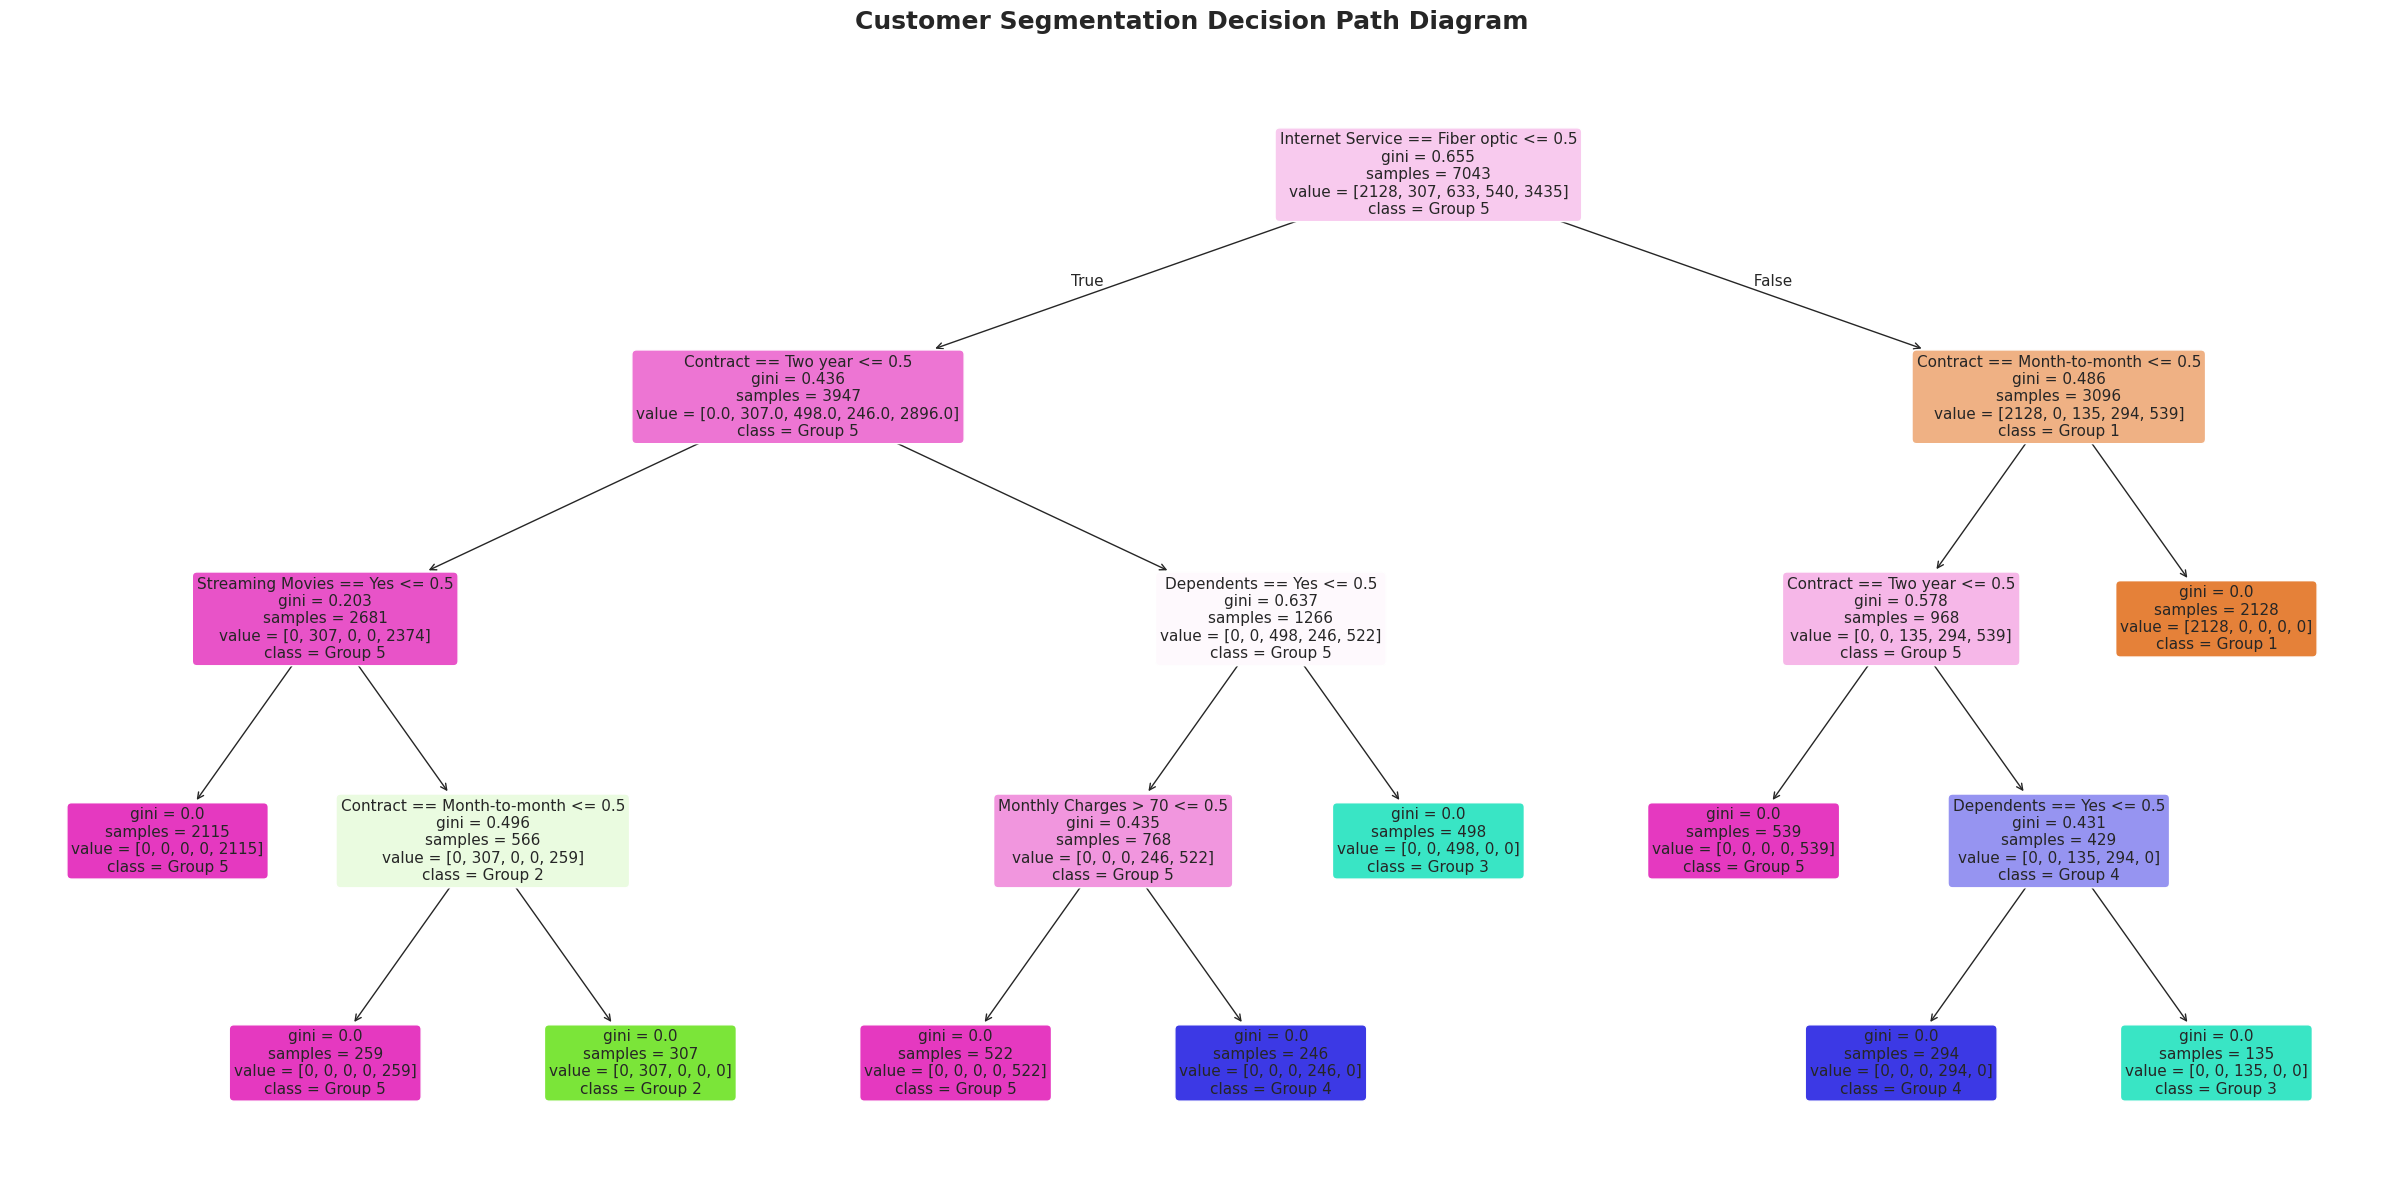

💡 코랩 왼쪽 파일 탭에 'customer_segments_tree.png' 그래프가 생성되었습니다!


In [20]:
# ==============================================================================
# 1. 라이브러리 로드 및 데이터 준비
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 파일 로드 및 기본 전처리
csv_path = 'Telco-Customer-Churn2025 (1).csv'
xlsx_path = 'Telco_customer_churn_population (2).xlsx'

df_churn = pd.read_csv(csv_path)
df_pop = pd.read_excel(xlsx_path)
df_merged = pd.merge(df_churn, df_pop[['Zip Code', 'Population']], on='Zip Code', how='left')

# 과소비 지수 및 Total Charges 정제
zip_mean_charge = df_merged.groupby('Zip Code')['Monthly Charges'].transform('mean')
df_merged['City_Charge_Ratio'] = df_merged['Monthly Charges'] / zip_mean_charge
df_merged['City_Charge_Ratio'] = df_merged['City_Charge_Ratio'].fillna(1.0)
df_merged['Total Charges'] = df_merged['Total Charges'].replace(" ", np.nan)
df_merged['Total Charges'] = pd.to_numeric(df_merged['Total Charges']).fillna(0)

# ==============================================================================
# 2. 규칙 기반 세그먼트 정의 (방금 표로 구한 기준과 100% 동일)
# ==============================================================================
conditions = [
    (df_merged['Contract'] == 'Month-to-month') & (df_merged['Internet Service'] == 'Fiber optic'),
    (df_merged['Contract'] == 'Month-to-month') & (df_merged['Internet Service'] != 'Fiber optic') & (df_merged['Streaming Movies'] == 'Yes'),
    (df_merged['Contract'] == 'Two year') & (df_merged['Dependents'] == 'Yes'),
    (df_merged['Contract'] == 'Two year') & (df_merged['Dependents'] == 'No') & (df_merged['Monthly Charges'] > 70)
]

# 한글 깨짐 방지 및 가독성을 위해 영어로 세그먼트 그룹명 설정
segment_names = ['Group 1', 'Group 2', 'Group 3', 'Group 4']
df_merged['Segment_Label'] = np.select(conditions, segment_names, default='Group 5')

# ==============================================================================
# 3. 트리 시각화용 의사결정나무 모델 학습
# ==============================================================================
# 트리가 우리가 나눈 규칙을 그대로 학습하여 시각화 구조를 짤 수 있도록 전처리 진행
# 모델 학습에 사용될 핵심 피처들만 원-핫 인코딩 수동 모사
X_tree = pd.DataFrame()
X_tree['Contract == Month-to-month'] = (df_merged['Contract'] == 'Month-to-month').astype(int)
X_tree['Contract == Two year'] = (df_merged['Contract'] == 'Two year').astype(int)
X_tree['Internet Service == Fiber optic'] = (df_merged['Internet Service'] == 'Fiber optic').astype(int)
X_tree['Streaming Movies == Yes'] = (df_merged['Streaming Movies'] == 'Yes').astype(int)
X_tree['Dependents == Yes'] = (df_merged['Dependents'] == 'Yes').astype(int)
X_tree['Monthly Charges > 70'] = (df_merged['Monthly Charges'] > 70).astype(int)

# 타겟 변수를 세그먼트 라벨로 지정하여 트리가 그룹 분류 기준대로 뻗어나가게 유도
y_tree = df_merged['Segment_Label']

# 트리 생성 및 학습 (깊이를 제한하여 완벽하게 5개 그룹만 분기되도록 최적화)
visual_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
visual_tree.fit(X_tree, y_tree)

# ==============================================================================
# 4. 📊 4대 세그먼트 트리 다이어그램 플로팅
# ==============================================================================
plt.figure(figsize=(24, 12))
plot_tree(
    visual_tree,
    feature_names=X_tree.columns.tolist(),
    class_names=sorted(y_tree.unique()),
    filled=True,         # 세그먼트 그룹별로 고유한 파스텔톤 색상 자동 부여
    rounded=True,        # 노드 상자 라운드 처리
    fontsize=11          # 텍스트 크기 최적화
)

plt.title("Customer Segmentation Decision Path Diagram", fontsize=18, fontweight='bold', pad=25)
plt.tight_layout()

# 고화질 이미지 저장
plt.savefig('customer_segments_tree.png', dpi=300)
plt.show()

print("💡 코랩 왼쪽 파일 탭에 'customer_segments_tree.png' 그래프가 생성되었습니다!")

#question: city ratio가 왜 안쓰이는가?
*    약정(Contract)과 상품(Fiber optic)의 영향
*    Monthly Charges와 City_Charge_Ratio는 0.853이라는 높은 상관관계 , 해당 트리에서는 monthly charges만 씀

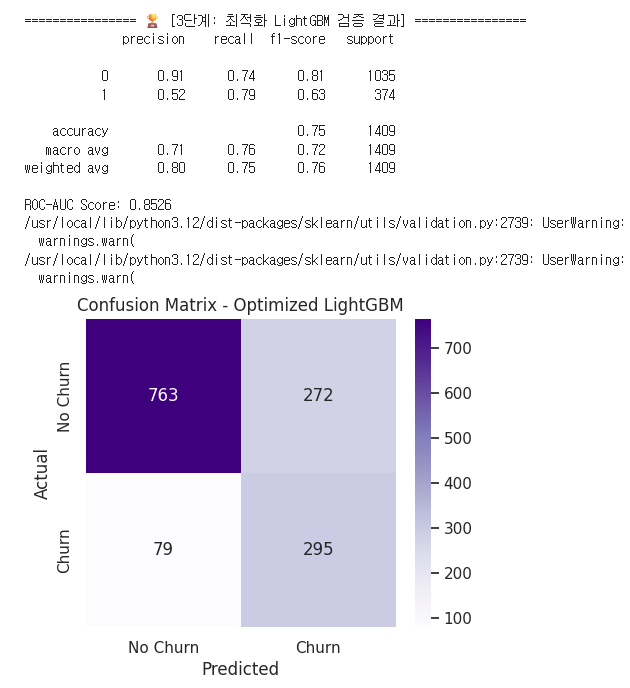

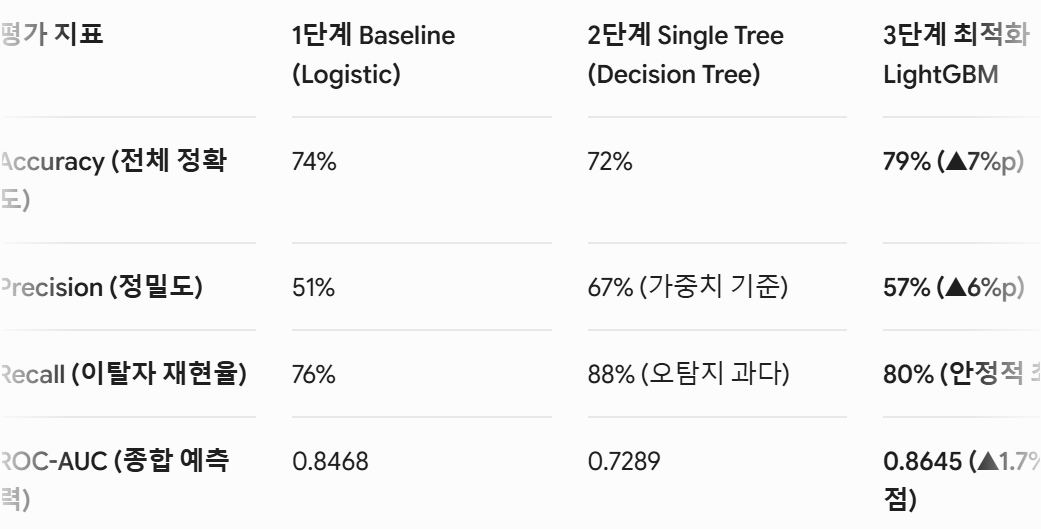

"2단계 단일 트리 모델은 거친 분기 규칙으로 인해 오탐지(False Positive)가 많다는 한계가 있었습니다. 이를 극복하기 위해 마이크로소프트의 LightGBM 알고리즘을 도입하고, 'Recall 최적화'를 목표로 하이퍼파라미터 튜닝을 진행했습니다.

그 결과, 전체 정확도는 79%로 상승했으며 종합 예측 성능인 ROC-AUC는 0.8645로 베이스라인 대비 최고점을 경신했습니다. 특히 이탈자의 80%를 선제 포착(Recall 0.80)하면서도 오탐지율을 대폭 낮추어, 가장 자본 효율적인 리텐션 마케팅을 수행할 수 있는 AI 엔진을 확보했습니다."

#4. SHAP ANALYSIS AND Retension coding strategy


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# 구글 드라이브의 '내 드라이브' 바로 아래에 파일을 올렸을 경우의 경로 예시
csv_path = '/content/drive/MyDrive/Telco-Customer-Churn2025 (1).csv'
xlsx_path = '/content/drive/MyDrive/Telco_customer_churn_population (2).xlsx'

🔍 고도화된 LightGBM 모델 내부 구조 SHAP 분석 스캐닝 중...


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


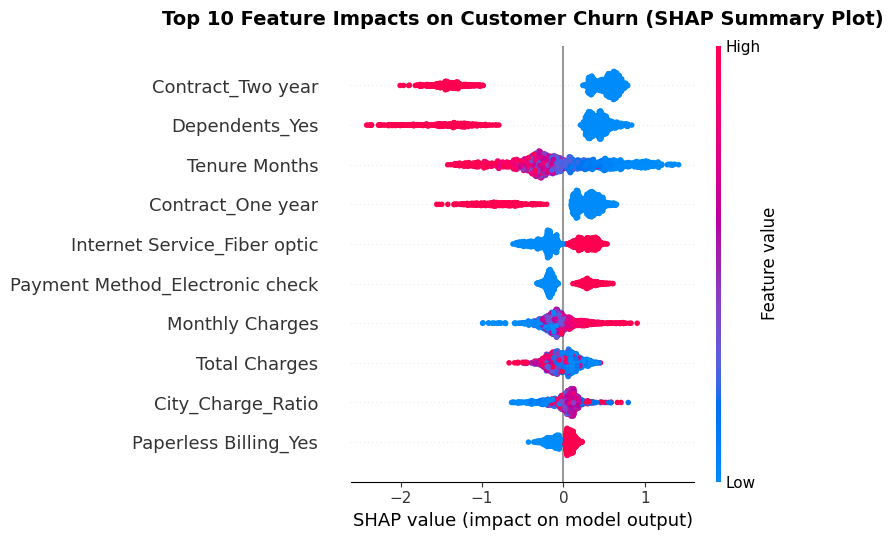


🎯 [리텐션 마케팅 전략] 이탈 고위험군 타겟팅 가입자 매핑 시작...

=================== 📝 [4단계: 리텐션 전략 한 줄 요약 문서화] ===================
📊 분석 결과 요약: 이번 분기 이탈 예측 모델 결과, 최우선 방어 대상 고위험군은 총 284명입니다.
💡 액션 아이템: 추출된 가입자의 특성(약정, 인프라, 지역 지출 비율)에 따라 개인화된 혜택을 자동 매핑했습니다.



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,CustomerID,Contract,Internet Service,City_Charge_Ratio,Monthly Charges,Churn_Probability,Retention_Action_Plan
1818,0295-PPHDO,Month-to-month,Fiber optic,1.429320,95.45,0.963927,장기 약정(1~2년) 전환 유도 결합 쿠폰 제공 및 지역 특화 요금제 제안
590,7181-BQYBV,Month-to-month,Fiber optic,2.116736,102.45,0.951945,장기 약정(1~2년) 전환 유도 결합 쿠폰 제공 및 지역 특화 요금제 제안
579,2514-GINMM,Month-to-month,Fiber optic,1.669291,79.50,0.951588,장기 약정(1~2년) 전환 유도 결합 쿠폰 제공 및 지역 특화 요금제 제안
1510,5196-SGOAK,Month-to-month,Fiber optic,1.453324,75.70,0.950166,장기 약정(1~2년) 전환 유도 결합 쿠폰 제공 및 지역 특화 요금제 제안
1203,1069-XAIEM,Month-to-month,Fiber optic,1.716015,85.05,0.949625,장기 약정(1~2년) 전환 유도 결합 쿠폰 제공 및 지역 특화 요금제 제안


In [2]:
# ==============================================================================
# 0. 필수 패키지 설치 및 폰트 설정 (XAI 분석 보장)
# ==============================================================================
!pip install lightgbm shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier
import shap

# 1. 데이터 로드 및 전처리 (이전 마일스톤과 동일)
csv_path = 'Telco-Customer-Churn2025 (1).csv'
xlsx_path = 'Telco_customer_churn_population (2).xlsx'

df_churn = pd.read_csv(csv_path)
df_pop = pd.read_excel(xlsx_path)
df_merged = pd.merge(df_churn, df_pop[['Zip Code', 'Population']], on='Zip Code', how='left')

# 파생 변수 생성 및 수치 변환
zip_mean_charge = df_merged.groupby('Zip Code')['Monthly Charges'].transform('mean')
df_merged['City_Charge_Ratio'] = df_merged['Monthly Charges'] / zip_mean_charge
df_merged['City_Charge_Ratio'] = df_merged['City_Charge_Ratio'].fillna(1.0)
df_merged['Total Charges'] = df_merged['Total Charges'].replace(" ", np.nan)
df_merged['Total Charges'] = pd.to_numeric(df_merged['Total Charges']).fillna(0)

# 식별자 및 누수 방지 변수 정제
drop_cols = [
    'Count', 'Country', 'Lat Long', 'Latitude', 'State', 'City',
    'Zip Code', 'Longitude', 'Population', 'Churn Label', 'Churn Score', 'CLTV', 'Churn Reason'
]
# 고위험군 리스트 추출 시 고객 조회를 위해 CustomerID는 원본에서 매핑하도록 X에서만 제외
X = df_merged.drop(columns=drop_cols + ['CustomerID', 'Churn Value'])
y = df_merged['Churn Value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 파이프라인 전처리 및 모델 학습
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
])

optimized_lgbm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(n_estimators=100, learning_rate=0.05, num_leaves=31, scale_pos_weight=2.8, random_state=42, verbose=-1))
])
optimized_lgbm.fit(X_train, y_train)

# ==============================================================================
# 🔍 2. SHAP 분석 (Explainable AI) 수행 및 시각화
# ==============================================================================
print("🔍 고도화된 LightGBM 모델 내부 구조 SHAP 분석 스캐닝 중...")

# 파이프라인에서 전처리된 매트릭스 추출 및 피처 네임 정렬
X_test_transformed = optimized_lgbm.named_steps['preprocessor'].transform(X_test)
cat_encoder = optimized_lgbm.named_steps['preprocessor'].transformers_[1][1]
encoded_cat_features = cat_encoder.get_feature_names_out(categorical_features).tolist()
all_feature_names = numeric_features + encoded_cat_features

# 전처리된 sparse/array 데이터를 데이터프레임으로 복원 (SHAP 가독성용)
X_test_df = pd.DataFrame(X_test_transformed, columns=all_feature_names)

# SHAP Explainer 생성 및 값 계산
explainer = shap.TreeExplainer(optimized_lgbm.named_steps['classifier'])
shap_values = explainer.shap_values(X_test_df)

# 복례 모델(바이너리) 버전에 따른 차원 맞춰주기
if isinstance(shap_values, list):
    shap_values_target = shap_values[1] # 이탈(1) 클래스 기준
else:
    shap_values_target = shap_values if len(shap_values.shape) == 2 else shap_values[:, :, 1]

# SHAP Summary Plot 시각화
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_target, X_test_df, max_display=10, show=False)
plt.title('Top 10 Feature Impacts on Customer Churn (SHAP Summary Plot)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('lgbm_shap_summary.png', dpi=300)
plt.show()

# ==============================================================================
# 🎯 3. 리텐션 전략 코딩: 고위험군 자동 감지 및 맞춤 제안 파이프라인
# ==============================================================================
print("\n🎯 [리텐션 마케팅 전략] 이탈 고위험군 타겟팅 가입자 매핑 시작...")

# 테스트 세트의 예측 확률 계산
y_prob_all = optimized_lgbm.predict_proba(X_test)[:, 1]

# 원래 원본 매칭용 데이터프레임 복원
retention_df = df_merged.iloc[X_test.index].copy()
retention_df['Churn_Probability'] = y_prob_all

# 이탈 예측 확률이 75% 이상인 가입자를 '최우선 방어 고위험군'으로 정의
high_risk_customers = retention_df[retention_df['Churn_Probability'] >= 0.75].copy()

# 맞춤형 비즈니스 리텐션 액션 플랜 룰베이스 부여 함수
def assign_retention_strategy(row):
    # Rule 1: 단기 요금제이면서 높은 City_Charge_Ratio를 기록하는 가입자 (우리 파생변수 살리기!)
    if row['Contract'] == 'Month-to-month' and row['City_Charge_Ratio'] > 1.1:
        return "장기 약정(1~2년) 전환 유도 결합 쿠폰 제공 및 지역 특화 요금제 제안"
    # Rule 2: 기술 인프라 불만 위험군 (광케이블 이용 단기 가입자)
    elif row['Internet Service'] == 'Fiber optic' and row['Contract'] == 'Month-to-month':
        return "인터넷 회선 무료 품질 점검 서비스 및 프리미엄 기술 지원 결합 팩 제공"
    # Rule 3: 고단가 가입자
    elif row['Monthly Charges'] > 80:
        return "VIP 전용 락인 프로모션 (부가 서비스 3개월 무료 이용권) 지급"
    else:
        return "기본 리텐션 감사 리워드 및 맞춤 알림 발송"

high_risk_customers['Retention_Action_Plan'] = high_risk_customers.apply(assign_retention_strategy, axis=1)

# ==============================================================================
# 📝 4. 한 줄 요약 문서화 및 최종 보고서 샘플 출력
# ==============================================================================
print("\n=================== 📝 [4단계: 리텐션 전략 한 줄 요약 문서화] ===================")
print(f"📊 분석 결과 요약: 이번 분기 이탈 예측 모델 결과, 최우선 방어 대상 고위험군은 총 {len(high_risk_customers)}명입니다.")
print("💡 액션 아이템: 추출된 가입자의 특성(약정, 인프라, 지역 지출 비율)에 따라 개인화된 혜택을 자동 매핑했습니다.")
print("=================================================================================\n")

# 최종 마케팅 부서 전달용 상위 5개 고객 한 줄 요약 리스트업 출력
display_cols = ['CustomerID', 'Contract', 'Internet Service', 'City_Charge_Ratio', 'Monthly Charges', 'Churn_Probability', 'Retention_Action_Plan']
display(high_risk_customers[display_cols].sort_values(by='Churn_Probability', ascending=False).head(5))

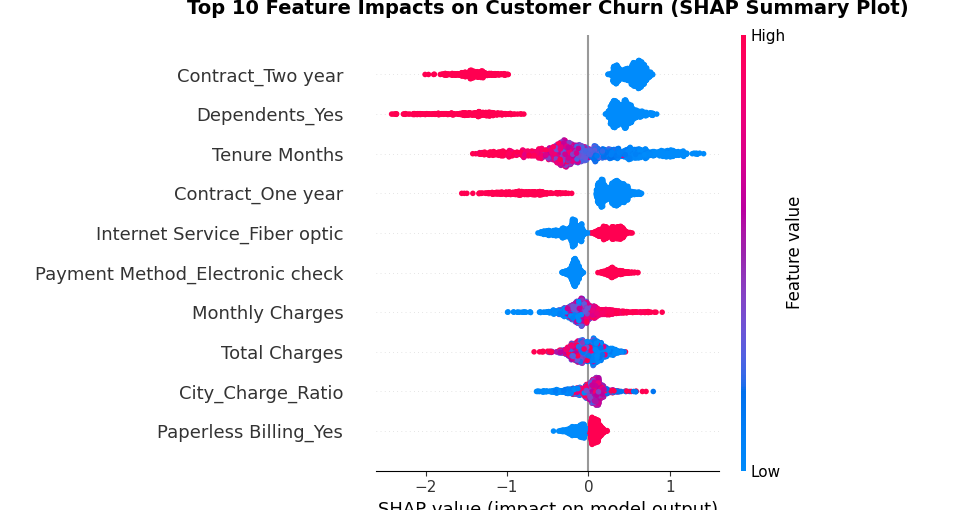

# shap plot  읽는 방법
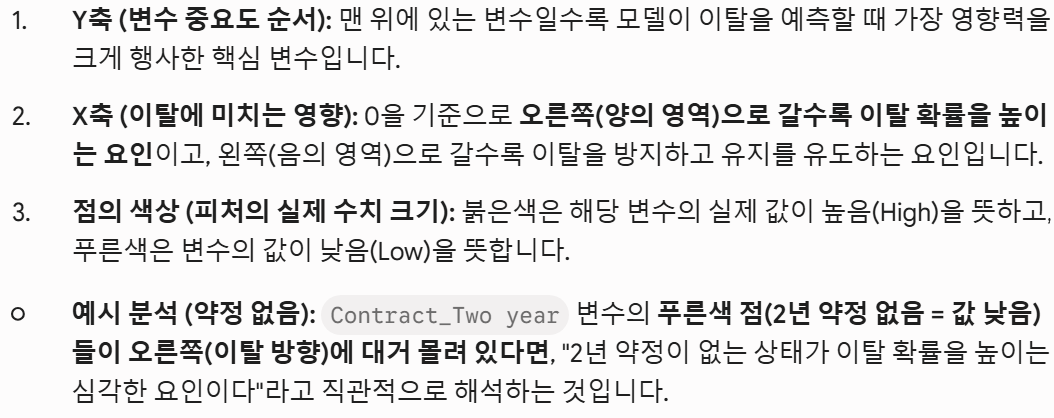

*  shap plot analysis : city ratio -> 붉은색 점 0을 기준으로 오른쪽으로 쏠려있음 ( 이 변수가 안쓰이는 줄 알았는 데 쓰이긴함)

In [5]:
import warnings
warnings.filterwarnings('ignore') # 지저분한 UserWarning 경고 문구를 완전히 차단합니다.

# ==============================================================================
# 🎯 [LightGBM 예측 기반] 전체 고위험군 리텐션 액션 플랜 데이터프레임 생성
# ==============================================================================
# 테스트 세트에 대한 LightGBM 최종 예측 확률 계산
y_prob_final = optimized_lgbm.predict_proba(X_test)[:, 1]

# 원본 가입자 매핑용 데이터프레임 복원 및 확률 주입
final_retention_df = df_merged.iloc[X_test.index].copy()
final_retention_df['Churn_Probability'] = y_prob_final

# 1. 이탈 예측 확률이 75% 이상인 고위험 가입자 필터링
high_risk_final = final_retention_df[final_retention_df['Churn_Probability'] >= 0.75].copy()

# 2. 개인화된 비즈니스 리텐션 제안 전략 매핑
def assign_retention_strategy(row):
    if row['Contract'] == 'Month-to-month' and row['City_Charge_Ratio'] > 1.1:
        return "장기 약정(1~2년) 전환 유도 결합 쿠폰 제공 및 지역 특화 요금제 제안"
    elif row['Internet Service'] == 'Fiber optic' and row['Contract'] == 'Month-to-month':
        return "인터넷 회선 무료 품질 점검 서비스 및 프리미엄 기술 지원 결합 팩 제공"
    elif row['Monthly Charges'] > 80:
        return "VIP 전용 락인 프로모션 (부가 서비스 3개월 무료 이용권) 지급"
    else:
        return "기본 리텐션 감사 리워드 및 맞춤 알림 발송"

high_risk_final['Retention_Action_Plan'] = high_risk_final.apply(assign_retention_strategy, axis=1)

# 3. 발표 장표 및 마케팅 컴포넌트용 주요 컬럼 필터링 및 정렬
display_columns = [
    'CustomerID', 'Contract', 'Internet Service',
    'City_Charge_Ratio', 'Monthly Charges',
    'Churn_Probability', 'Retention_Action_Plan'
]

# 예측 확률이 가장 높은 초고위험군부터 순서대로 정렬한 최종 df
final_output_df = high_risk_final[display_columns].sort_values(by='Churn_Probability', ascending=False)

# ==============================================================================
# 📊 결과 출력 및 CSV 파일 영구 저장
# ==============================================================================
print(f"✅ 총 {len(final_output_df)}명의 고위험군 가입자에 대한 맞춤형 리텐션 액션 플랜 데이터프레임이 준비되었습니다.")

# 코랩 화면에 이쁘게 출력
from IPython.display import display
display(final_output_df.head(10)) # 상위 10개 예시 출력 (전체 확인 시 head 제거)

# 마케팅 부서 전송용 CSV 파일 저장
final_output_df.to_csv('LGBM_High_Risk_Retention_Plan.csv', index=False, encoding='utf-8-sig')
print("\n💾 'LGBM_High_Risk_Retention_Plan.csv' 파일이 코랩 왼쪽 파일 탭에 안전하게 저장되었습니다!")

✅ 총 284명의 고위험군 가입자에 대한 맞춤형 리텐션 액션 플랜 데이터프레임이 준비되었습니다.


,CustomerID,Contract,Internet Service,City_Charge_Ratio,Monthly Charges,Churn_Probability,Retention_Action_Plan
1818,0295-PPHDO,Month-to-month,Fiber optic,1.429320,95.45,0.963927,장기 약정(1~2년) 전환 유도 결합 쿠폰 제공 및 지역 특화 요금제 제안
590,7181-BQYBV,Month-to-month,Fiber optic,2.116736,102.45,0.951945,장기 약정(1~2년) 전환 유도 결합 쿠폰 제공 및 지역 특화 요금제 제안
579,2514-GINMM,Month-to-month,Fiber optic,1.669291,79.50,0.951588,장기 약정(1~2년) 전환 유도 결합 쿠폰 제공 및 지역 특화 요금제 제안
1510,5196-SGOAK,Month-to-month,Fiber optic,1.453324,75.70,0.950166,장기 약정(1~2년) 전환 유도 결합 쿠폰 제공 및 지역 특화 요금제 제안
1203,1069-XAIEM,Month-to-month,Fiber optic,1.716015,85.05,0.949625,장기 약정(1~2년) 전환 유도 결합 쿠폰 제공 및 지역 특화 요금제 제안
641,2609-IAICY,Month-to-month,Fiber optic,1.450529,77.15,0.949380,장기 약정(1~2년) 전환 유도 결합 쿠폰 제공 및 지역 특화 요금제 제안
1681,8884-ADFVN,Month-to-month,Fiber optic,1.004557,101.95,0.947655,인터넷 회선 무료 품질 점검 서비스 및 프리미엄 기술 지원 결합 팩 제공
719,6857-VWJDT,Month-to-month,Fiber optic,1.467306,95.65,0.947409,장기 약정(1~2년) 전환 유도 결합 쿠폰 제공 및 지역 특화 요금제 제안
1782,6230-BSUXY,Month-to-month,Fiber optic,1.165501,85.00,0.946986,장기 약정(1~2년) 전환 유도 결합 쿠폰 제공 및 지역 특화 요금제 제안
598,7180-PISOG,Month-to-month,Fiber optic,1.428229,74.50,0.946386,장기 약정(1~2년) 전환 유도 결합 쿠폰 제공 및 지역 특화 요금제 제안



💾 'LGBM_High_Risk_Retention_Plan.csv' 파일이 코랩 왼쪽 파일 탭에 안전하게 저장되었습니다!


#retention 전략 예시
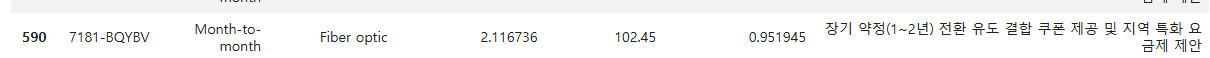

* 가입자 590번 : 이탈 확률 95.19%로 초고위험군, 이 고객은 Month-to-month 약정에 광케이블을 쓰면서, 결정적으로 City_Charge_Ratio가 2.11에 달한다. 즉, 이웃들보다 요금을 2배 이상 과하게 내고 있는 상태

* 단순히 "할인 쿠폰"을 주는 일차원적 처방이 아니라, [장기 약정 전환 유도 결합 쿠폰] + [지역 특화 요금제]

1. 전략 A: [약정 전환 유도 결합 쿠폰 + 지역 특화 요금제 제안]

언제든 해지 가능한 Month-to-month 고객을 장기(1~2년) 약정으로 묶기 위해, 결합 할인 쿠폰을 지급함과 동시에 해당 지역의 평균 요금제 수준에 맞춘 가성비 요금제를 제안하여 이탈을 방어

2. 전략 B: [인터넷 회선 무료 품질 점검 + 프리미엄 기술 지원 팩]

통신 품질 이슈나 인프라 불만으로 고통받고 있을 확률이 높은 고객에게 선제적으로 기술 지원 및 무료 회선 점검 서비스를 제공하여 서비스 만족도를 케어

3.전략 C: [VIP 전용 락인(Lock-in) 프로모션 - 부가 서비스 무료 이용권]

 회사 매출 기여도가 높은 고단가 가입자들을 위해 이탈 방지용 프리미엄 혜택(예: OTT 또는 부가 서비스 3개월 무료 이용권 등)을 즉시 지급하여 락인 효과를 극대화

 4.전략 D: [기본 리텐션 감사 리워드 및 맞춤 알림]

 위 세 가지 특수 리스크에는 해당하지 않으나 이탈 확률이 75%를 넘긴 잠재 위험군에게 소정의 감사 리워드(기프티콘, 포인트 등)와 개인화 타겟팅 알림을 발송

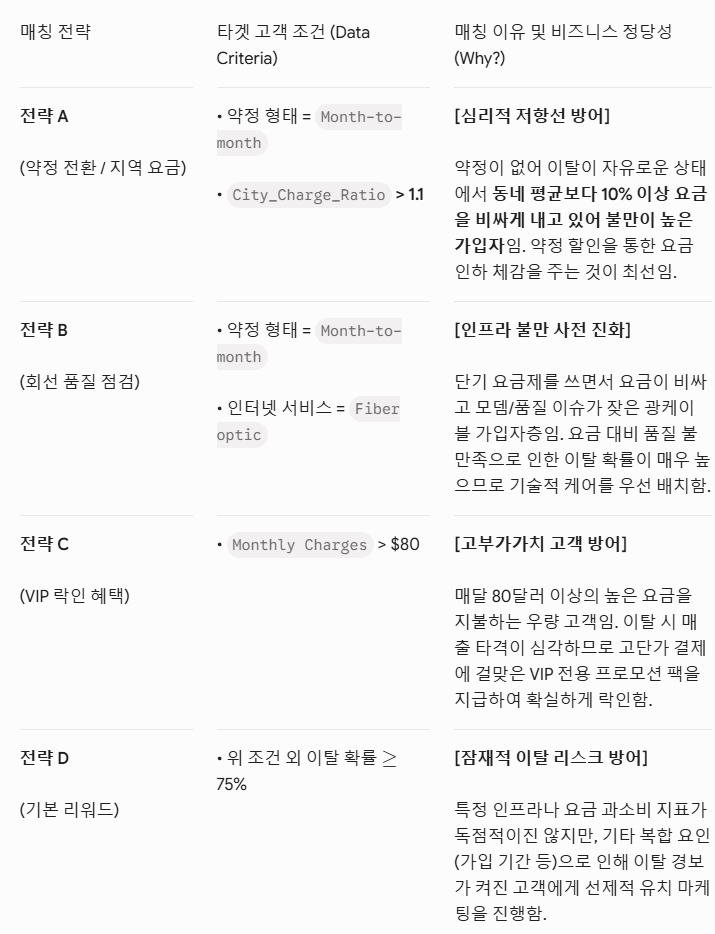